# 05. Transformer для определения границ предложений

**Цель:** превзойти CatBoost (F1=0.984) с помощью fine-tuned трансформера.

**Модель:** `cointegrated/rubert-tiny2` — 29M параметров, контекст 2048 токенов, быстрый инференс на CPU.

**Подход:** token classification — каждый BPE-токен получает метку «граница» / «не граница».
Маппинг char→token через `offset_mapping`.

In [1]:
import json
import random
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import AutoTokenizer, AutoModelForTokenClassification, get_linear_schedule_with_warmup

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.size"] = 12

SEED = 42
MODEL_NAME = "cointegrated/rubert-tiny2"
MAX_LEN = 2048
DATA_PATH = Path("../data/processed/sentences.jsonl")
EXCLUDE_IDS = {"text_833", "text_843"}

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cpu")
print(f"Device: {device}")

with open(DATA_PATH, encoding="utf-8") as f:
    dataset = [json.loads(line) for line in f]
dataset = [r for r in dataset if r["id"] not in EXCLUDE_IDS]
print(f"Текстов: {len(dataset)}")
print(f"Предложений: {sum(r['num_sentences'] for r in dataset)}")

Device: cpu
Текстов: 532
Предложений: 20740


## 1. Train/test split

Точно такой же split, как в notebook 04 (CatBoost), для честного сравнения.

In [2]:
random.seed(SEED)
text_ids = [r["id"] for r in dataset]
random.shuffle(text_ids)

split_idx = int(len(text_ids) * 0.7)
train_ids = set(text_ids[:split_idx])
test_ids = set(text_ids[split_idx:])

train_data = [r for r in dataset if r["id"] in train_ids]
test_data = [r for r in dataset if r["id"] in test_ids]

# fit/val split (80/20 от train, как в notebook 04)
random.seed(SEED)
train_text_ids_list = [r["id"] for r in train_data]
random.shuffle(train_text_ids_list)
val_split = int(len(train_text_ids_list) * 0.8)
fit_ids = set(train_text_ids_list[:val_split])
val_ids = set(train_text_ids_list[val_split:])

fit_data = [r for r in train_data if r["id"] in fit_ids]
val_data = [r for r in train_data if r["id"] in val_ids]

print(f"Train: {len(train_data)} текстов, {sum(r['num_sentences'] for r in train_data)} предложений")
print(f"  Fit: {len(fit_data)}, Val: {len(val_data)}")
print(f"Test:  {len(test_data)} текстов, {sum(r['num_sentences'] for r in test_data)} предложений")

Train: 372 текстов, 14525 предложений
  Fit: 297, Val: 75
Test:  160 текстов, 6215 предложений


## 2. Токенизация: sanity check

Проверяем, что все тексты влезают в контекст 2048 токенов, и смотрим, как `offset_mapping` связывает токены с позициями в тексте.

In [3]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Проверяем максимальное количество токенов
token_counts = []
for rec in dataset:
    n_tokens = len(tokenizer(rec["clean_text"], add_special_tokens=True)["input_ids"])
    token_counts.append(n_tokens)

token_counts = np.array(token_counts)
print(f"Токенов: min={token_counts.min()}, median={np.median(token_counts):.0f}, "
      f"P95={np.percentile(token_counts, 95):.0f}, max={token_counts.max()}")
assert token_counts.max() <= MAX_LEN, f"Есть тексты длиннее {MAX_LEN} токенов!"
print(f"Все тексты <= {MAX_LEN} токенов — sliding window не нужен.")

# Демо: offset_mapping для первого текста
sample = dataset[0]
enc = tokenizer(sample["clean_text"], return_offsets_mapping=True, add_special_tokens=True)
print(f"\nПример: {len(sample['clean_text'])} символов → {len(enc['input_ids'])} токенов")

print("\nПервые 10 токенов:")
for i in range(min(10, len(enc["input_ids"]))):
    tid = enc["input_ids"][i]
    cs, ce = enc["offset_mapping"][i]
    char_span = sample["clean_text"][cs:ce] if cs != ce else "[SPECIAL]"
    print(f"  Token {i}: offset=({cs},{ce}), text='{char_span}'")

# Показываем маппинг границ → токенов
sents = sample["sentences"]
boundary_positions = sorted(sents[i]["end"] for i in range(len(sents) - 1))
print(f"\nПервые 3 границы (char positions): {boundary_positions[:3]}")
for bp in boundary_positions[:3]:
    ctx = sample["clean_text"][max(0, bp-15):bp+15]
    for i, (cs, ce) in enumerate(enc["offset_mapping"]):
        if cs <= bp < ce:
            tok_text = sample["clean_text"][cs:ce]
            print(f"  Граница {bp} '...{ctx}...' → токен {i} ({cs}:{ce}) = '{tok_text}'")
            break

Токенов: min=259, median=699, P95=1140, max=1504
Все тексты <= 2048 токенов — sliding window не нужен.

Пример: 3045 символов → 655 токенов

Первые 10 токенов:
  Token 0: offset=(0,0), text='[SPECIAL]'
  Token 1: offset=(0,7), text='Сегодня'
  Token 2: offset=(8,9), text='я'
  Token 3: offset=(10,17), text='увидела'
  Token 4: offset=(18,25), text='ребёнка'
  Token 5: offset=(25,26), text='.'
  Token 6: offset=(26,27), text='.'
  Token 7: offset=(27,28), text='.'
  Token 8: offset=(29,35), text='Многие'
  Token 9: offset=(36,43), text='говорят'

Первые 3 границы (char positions): [28, 143, 225]


## 3. Dataset и DataLoader

Для каждого токена:
- **label=1** если в его char-span попадает граница предложения
- **label=0** если не попадает
- **label=-100** для спецтокенов `[CLS]`, `[SEP]` (игнорируются в loss)

In [4]:
def get_true_boundaries(rec):
    """Истинные границы: позиции end каждого предложения (кроме последнего)."""
    sents = rec["sentences"]
    return set(sents[i]["end"] for i in range(len(sents) - 1))


class SentenceBoundaryDataset(Dataset):
    def __init__(self, records, tokenizer, max_len=MAX_LEN):
        self.items = []
        for rec in records:
            enc = tokenizer(
                rec["clean_text"],
                return_offsets_mapping=True,
                add_special_tokens=True,
                max_length=max_len,
                truncation=True,
            )
            boundary_positions = get_true_boundaries(rec)

            # Инициализируем метки: -100 для спецтокенов, 0 для остальных
            labels = []
            for cs, ce in enc["offset_mapping"]:
                if cs == 0 and ce == 0:
                    labels.append(-100)
                else:
                    labels.append(0)

            # Маппинг границ → токены через char_to_token()
            # Если граница на пробеле (нет токена), берём следующий токен
            for bp in boundary_positions:
                token_idx = enc.char_to_token(bp)
                if token_idx is not None:
                    labels[token_idx] = 1
                else:
                    # Граница на пробеле — ищем ближайший токен справа
                    for pos in range(bp + 1, min(bp + 5, len(rec["clean_text"]))):
                        token_idx = enc.char_to_token(pos)
                        if token_idx is not None:
                            labels[token_idx] = 1
                            break

            self.items.append({
                "input_ids": enc["input_ids"],
                "attention_mask": enc["attention_mask"],
                "labels": labels,
            })

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        return self.items[idx]


def collate_fn(batch):
    max_len = max(len(item["input_ids"]) for item in batch)
    pad_id = tokenizer.pad_token_id
    input_ids, attention_mask, labels = [], [], []
    for item in batch:
        pad_len = max_len - len(item["input_ids"])
        input_ids.append(item["input_ids"] + [pad_id] * pad_len)
        attention_mask.append(item["attention_mask"] + [0] * pad_len)
        labels.append(item["labels"] + [-100] * pad_len)
    return {
        "input_ids": torch.tensor(input_ids, dtype=torch.long),
        "attention_mask": torch.tensor(attention_mask, dtype=torch.long),
        "labels": torch.tensor(labels, dtype=torch.long),
    }


BATCH_SIZE = 2  # MPS memory limit — длинные последовательности ~1000+ токенов

fit_dataset = SentenceBoundaryDataset(fit_data, tokenizer)
val_dataset = SentenceBoundaryDataset(val_data, tokenizer)

# Баланс классов на уровне токенов
all_labels = [l for item in fit_dataset.items for l in item["labels"] if l != -100]
pos_count = sum(1 for l in all_labels if l == 1)
neg_count = sum(1 for l in all_labels if l == 0)
pos_ratio = pos_count / len(all_labels)
print(f"Токен-level баланс: {pos_count} positive ({100*pos_ratio:.1f}%), {neg_count} negative")
print(f"Соотношение neg/pos: {neg_count/pos_count:.1f}")

fit_loader = DataLoader(fit_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
print(f"\nFit: {len(fit_dataset)} текстов, {len(fit_loader)} batches")
print(f"Val: {len(val_dataset)} текстов, {len(val_loader)} batches")

Токен-level баланс: 11223 positive (5.3%), 201798 negative
Соотношение neg/pos: 18.0

Fit: 297 текстов, 149 batches
Val: 75 текстов, 38 batches


## 4. Обучение

Fine-tune `rubert-tiny2` с weighted CrossEntropyLoss. Early stopping по F1 на валидации (tolerance=2, как в notebook 04).

In [5]:
# --- Функции оценки (идентичны notebook 04) ---

def evaluate(records, predict_fn, tolerance=2):
    """Оценивает predict_fn на записях. predict_fn(clean_text) -> set of positions."""
    total_tp = total_fp = total_fn = 0
    for rec in records:
        true_bd = get_true_boundaries(rec)
        pred_bd = predict_fn(rec["clean_text"])

        matched_true = set()
        matched_pred = set()
        for pb in pred_bd:
            for tb in true_bd:
                if abs(pb - tb) <= tolerance and tb not in matched_true:
                    matched_true.add(tb)
                    matched_pred.add(pb)
                    break

        total_tp += len(matched_pred)
        total_fp += len(pred_bd) - len(matched_pred)
        total_fn += len(true_bd) - len(matched_true)

    precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0
    recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    return {"TP": total_tp, "FP": total_fp, "FN": total_fn,
            "Precision": precision, "Recall": recall, "F1": f1}


def predict_boundaries(text, model, tokenizer, threshold=0.5):
    """Предсказывает границы предложений в тексте."""
    model_device = next(model.parameters()).device
    enc = tokenizer(text, return_offsets_mapping=True, add_special_tokens=True,
                    max_length=MAX_LEN, truncation=True, return_tensors="pt")
    offset_mapping = enc.pop("offset_mapping")[0]
    enc = {k: v.to(model_device) for k, v in enc.items()}

    with torch.no_grad():
        logits = model(**enc).logits[0]
    probs = torch.softmax(logits, dim=-1)[:, 1].cpu().numpy()

    boundaries = set()
    for i in range(len(probs)):
        if probs[i] >= threshold:
            cs, ce = offset_mapping[i].tolist()
            if cs == 0 and ce == 0:
                continue
            boundaries.add(cs)
    return boundaries


def make_predict_fn(model, tokenizer, threshold):
    def predict_fn(text):
        return predict_boundaries(text, model, tokenizer, threshold)
    return predict_fn

In [6]:
model = AutoModelForTokenClassification.from_pretrained(MODEL_NAME, num_labels=2)
model.to(device)

# Weighted loss: усиленный вес для границ
scale = 1.0
weight = torch.tensor([1.0, (neg_count / pos_count) * scale], device=device)
criterion = nn.CrossEntropyLoss(weight=weight, ignore_index=-100)
print(f"Loss weights: [1.0, {weight[1].item():.1f}] (scale={scale})")

EPOCHS = 30
BATCH_SIZE = 2
GRAD_ACCUM = 8  # effective batch = BATCH_SIZE * GRAD_ACCUM = 16
LR = 3e-5
WARMUP_RATIO = 0.1

fit_loader = DataLoader(fit_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
total_steps = len(fit_loader) * EPOCHS // GRAD_ACCUM
warmup_steps = int(total_steps * WARMUP_RATIO)
scheduler = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)
print(f"Epochs: {EPOCHS}, batch_size: {BATCH_SIZE}, grad_accum: {GRAD_ACCUM} (effective: {BATCH_SIZE*GRAD_ACCUM})")
print(f"Optimizer steps: {total_steps}, warmup: {warmup_steps}")

# --- Training loop ---
best_val_f1 = 0
best_epoch = 0
patience = 7
patience_counter = 0
history = {"train_loss": [], "val_f1": [], "val_precision": [], "val_recall": []}
best_state = None

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    n_batches = 0
    optimizer.zero_grad()

    for step, batch in enumerate(fit_loader):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        loss = criterion(outputs.logits.view(-1, 2), labels.view(-1))
        loss = loss / GRAD_ACCUM
        loss.backward()

        if (step + 1) % GRAD_ACCUM == 0 or (step + 1) == len(fit_loader):
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()

        total_loss += loss.item() * GRAD_ACCUM
        n_batches += 1

    avg_loss = total_loss / n_batches

    # Validation
    model.eval()
    pred_fn = make_predict_fn(model, tokenizer, 0.5)
    val_result = evaluate(val_data, pred_fn)

    history["train_loss"].append(avg_loss)
    history["val_f1"].append(val_result["F1"])
    history["val_precision"].append(val_result["Precision"])
    history["val_recall"].append(val_result["Recall"])

    print(f"Epoch {epoch+1:2d}/{EPOCHS}: loss={avg_loss:.4f}  "
          f"val P={val_result['Precision']:.3f} R={val_result['Recall']:.3f} F1={val_result['F1']:.3f}  "
          f"FP={val_result['FP']} FN={val_result['FN']}")

    if val_result["F1"] > best_val_f1:
        best_val_f1 = val_result["F1"]
        best_epoch = epoch + 1
        patience_counter = 0
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\nEarly stopping at epoch {epoch+1}. Best: epoch {best_epoch} (F1={best_val_f1:.3f})")
            break

print(f"\nBest epoch: {best_epoch}, val F1: {best_val_f1:.3f}")

Loading weights:   0%|          | 0/53 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     | 
-------------------------------------------+------------+-
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expec

Loss weights: [1.0, 18.0] (scale=1.0)
Epochs: 30, batch_size: 2, grad_accum: 8 (effective: 16)
Optimizer steps: 558, warmup: 55
Epoch  1/30: loss=0.7642  val P=0.065 R=0.586 F1=0.117  FP=24636 FN=1212
Epoch  2/30: loss=0.6190  val P=0.261 R=0.957 F1=0.410  FP=7945 FN=127
Epoch  3/30: loss=0.3401  val P=0.628 R=0.994 F1=0.770  FP=1722 FN=17
Epoch  4/30: loss=0.0935  val P=0.721 R=0.997 F1=0.837  FP=1128 FN=8
Epoch  5/30: loss=0.0417  val P=0.758 R=0.997 F1=0.861  FP=930 FN=10
Epoch  6/30: loss=0.0329  val P=0.782 R=0.997 F1=0.877  FP=812 FN=10
Epoch  7/30: loss=0.0296  val P=0.811 R=0.995 F1=0.894  FP=680 FN=14
Epoch  8/30: loss=0.0270  val P=0.799 R=0.998 F1=0.887  FP=736 FN=7
Epoch  9/30: loss=0.0252  val P=0.822 R=0.996 F1=0.901  FP=630 FN=12
Epoch 10/30: loss=0.0242  val P=0.817 R=0.997 F1=0.898  FP=653 FN=9
Epoch 11/30: loss=0.0237  val P=0.817 R=0.998 F1=0.898  FP=656 FN=7
Epoch 12/30: loss=0.0225  val P=0.826 R=0.997 F1=0.903  FP=615 FN=10
Epoch 13/30: loss=0.0213  val P=0.833 R=

## 5. Кривые обучения

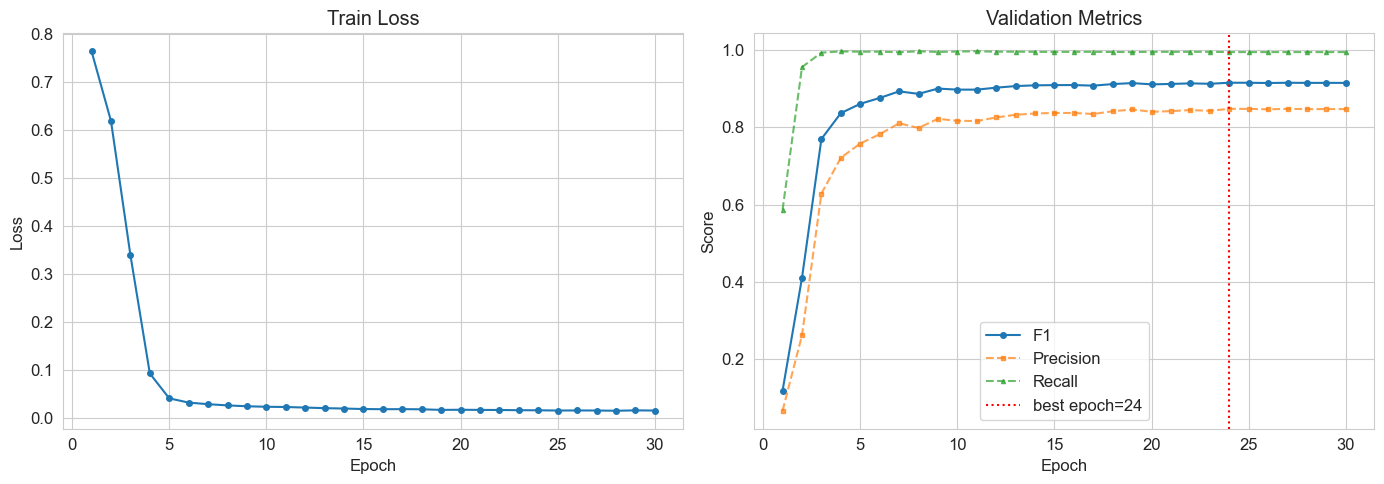

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, len(history["train_loss"]) + 1)

ax1.plot(epochs_range, history["train_loss"], "o-", ms=4)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Train Loss")

ax2.plot(epochs_range, history["val_f1"], "o-", label="F1", ms=4)
ax2.plot(epochs_range, history["val_precision"], "s--", alpha=0.7, label="Precision", ms=3)
ax2.plot(epochs_range, history["val_recall"], "^--", alpha=0.7, label="Recall", ms=3)
ax2.axvline(best_epoch, color="red", ls=":", label=f"best epoch={best_epoch}")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Score")
ax2.set_title("Validation Metrics")
ax2.legend()

plt.tight_layout()
plt.show()

## 6. Подбор порога

Порог 0.5 не обязательно оптимален. Подбираем на валидации (аналогично CatBoost в notebook 04).

  threshold=0.050: P=0.734 R=0.999 F1=0.846  FP=1063 FN=3
  threshold=0.075: P=0.753 R=0.998 F1=0.859  FP=958 FN=5
  threshold=0.100: P=0.780 R=0.998 F1=0.876  FP=823 FN=6
  threshold=0.125: P=0.802 R=0.998 F1=0.890  FP=720 FN=6
  threshold=0.150: P=0.813 R=0.998 F1=0.896  FP=673 FN=6
  threshold=0.175: P=0.823 R=0.998 F1=0.902  FP=631 FN=6
  threshold=0.200: P=0.825 R=0.998 F1=0.903  FP=619 FN=7
  threshold=0.225: P=0.828 R=0.998 F1=0.905  FP=608 FN=7
  threshold=0.250: P=0.829 R=0.998 F1=0.906  FP=601 FN=7
  threshold=0.275: P=0.831 R=0.998 F1=0.907  FP=595 FN=7
  threshold=0.300: P=0.833 R=0.998 F1=0.908  FP=588 FN=7
  threshold=0.325: P=0.835 R=0.998 F1=0.909  FP=576 FN=7
  threshold=0.350: P=0.838 R=0.997 F1=0.911  FP=565 FN=8
  threshold=0.375: P=0.840 R=0.997 F1=0.912  FP=556 FN=9
  threshold=0.400: P=0.843 R=0.997 F1=0.913  FP=545 FN=9
  threshold=0.425: P=0.843 R=0.996 F1=0.913  FP=542 FN=11
  threshold=0.450: P=0.845 R=0.996 F1=0.914  FP=537 FN=12
  threshold=0.475: P=0.846 R

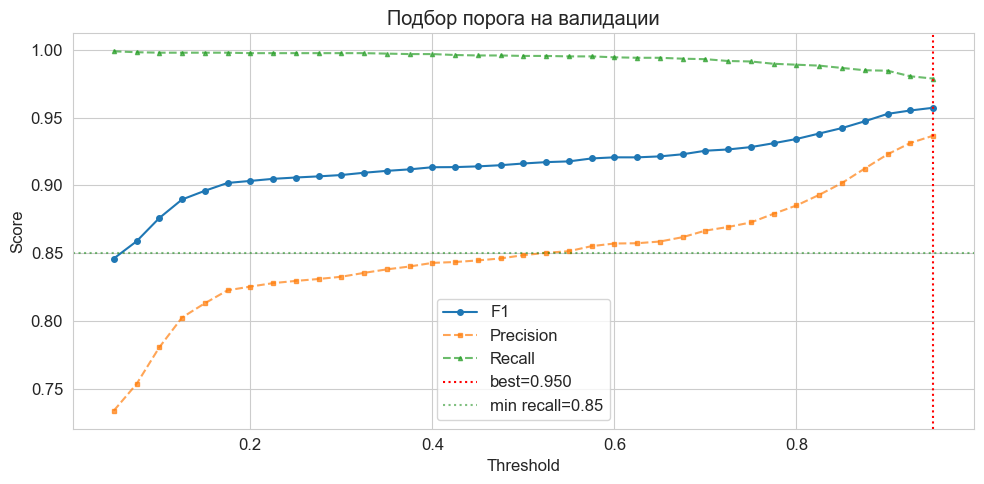

In [8]:
# Загружаем лучшие веса
model.load_state_dict(best_state)
model.to(device)
model.eval()

MIN_RECALL = 0.85
thresholds = np.arange(0.05, 0.96, 0.025)
val_results = []

for thr in thresholds:
    pred_fn = make_predict_fn(model, tokenizer, thr)
    res = evaluate(val_data, pred_fn)
    val_results.append(res)
    print(f"  threshold={thr:.3f}: P={res['Precision']:.3f} R={res['Recall']:.3f} F1={res['F1']:.3f}"
          f"  FP={res['FP']} FN={res['FN']}")

eligible = [(i, val_results[i]) for i in range(len(val_results))
            if val_results[i]["Recall"] >= MIN_RECALL]

if eligible:
    best_idx = max(eligible, key=lambda x: x[1]["F1"])[0]
else:
    best_idx = max(range(len(val_results)), key=lambda i: val_results[i]["F1"])
    print(f"\nНи один порог не даёт recall >= {MIN_RECALL}, берём лучший F1")

best_threshold = thresholds[best_idx]
print(f"\nОптимальный порог: {best_threshold:.3f}")
print(f"  P={val_results[best_idx]['Precision']:.3f} "
      f"R={val_results[best_idx]['Recall']:.3f} "
      f"F1={val_results[best_idx]['F1']:.3f}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, [r["F1"] for r in val_results], "o-", label="F1", ms=4)
ax.plot(thresholds, [r["Precision"] for r in val_results], "s--", alpha=0.7, label="Precision", ms=3)
ax.plot(thresholds, [r["Recall"] for r in val_results], "^--", alpha=0.7, label="Recall", ms=3)
ax.axvline(best_threshold, color="red", ls=":", label=f"best={best_threshold:.3f}")
ax.axhline(MIN_RECALL, color="green", ls=":", alpha=0.5, label=f"min recall={MIN_RECALL}")
ax.set_xlabel("Threshold")
ax.set_ylabel("Score")
ax.set_title("Подбор порога на валидации")
ax.legend()
plt.tight_layout()
plt.show()

## 7. Оценка на тестовой выборке

Переобучаем на полном train (372 текста) с лучшим числом эпох. Сравниваем с baseline и CatBoost.

In [9]:
print(f"Переобучение на полном train ({len(train_data)} текстов) за {best_epoch} эпох...")

model_final = AutoModelForTokenClassification.from_pretrained(MODEL_NAME, num_labels=2)
model_final.to(device)

train_dataset = SentenceBoundaryDataset(train_data, tokenizer)
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, collate_fn=collate_fn)

optimizer_final = AdamW(model_final.parameters(), lr=LR, weight_decay=0.01)
total_steps_final = len(train_loader) * best_epoch // GRAD_ACCUM
warmup_final = int(total_steps_final * WARMUP_RATIO)
scheduler_final = get_linear_schedule_with_warmup(optimizer_final, warmup_final, total_steps_final)

for epoch in range(best_epoch):
    model_final.train()
    total_loss = 0
    n_batches = 0
    optimizer_final.zero_grad()

    for step, batch in enumerate(train_loader):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model_final(input_ids=input_ids, attention_mask=attention_mask)
        loss = criterion(outputs.logits.view(-1, 2), labels.view(-1))
        loss = loss / GRAD_ACCUM
        loss.backward()

        if (step + 1) % GRAD_ACCUM == 0 or (step + 1) == len(train_loader):
            torch.nn.utils.clip_grad_norm_(model_final.parameters(), 1.0)
            optimizer_final.step()
            scheduler_final.step()
            optimizer_final.zero_grad()

        total_loss += loss.item() * GRAD_ACCUM
        n_batches += 1

    print(f"  Epoch {epoch+1}/{best_epoch}: loss={total_loss/n_batches:.4f}")

# Оценка на тесте
model_final.eval()
predict_transformer = make_predict_fn(model_final, tokenizer, best_threshold)
test_result = evaluate(test_data, predict_transformer)

print(f"\n=== Transformer (rubert-tiny2, threshold={best_threshold:.3f}) ===")
print(f"  TP={test_result['TP']}, FP={test_result['FP']}, FN={test_result['FN']}")
print(f"  Precision = {test_result['Precision']:.3f}")
print(f"  Recall    = {test_result['Recall']:.3f}")
print(f"  F1        = {test_result['F1']:.3f}")

Переобучение на полном train (372 текстов) за 24 эпох...


Loading weights:   0%|          | 0/53 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     | 
-------------------------------------------+------------+-
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expec

  Epoch 1/24: loss=0.7222
  Epoch 2/24: loss=0.6080
  Epoch 3/24: loss=0.3841
  Epoch 4/24: loss=0.1757
  Epoch 5/24: loss=0.0787
  Epoch 6/24: loss=0.0501
  Epoch 7/24: loss=0.0405
  Epoch 8/24: loss=0.0356
  Epoch 9/24: loss=0.0333
  Epoch 10/24: loss=0.0316
  Epoch 11/24: loss=0.0291
  Epoch 12/24: loss=0.0280
  Epoch 13/24: loss=0.0268
  Epoch 14/24: loss=0.0264
  Epoch 15/24: loss=0.0263
  Epoch 16/24: loss=0.0255
  Epoch 17/24: loss=0.0242
  Epoch 18/24: loss=0.0237
  Epoch 19/24: loss=0.0236
  Epoch 20/24: loss=0.0235
  Epoch 21/24: loss=0.0240
  Epoch 22/24: loss=0.0236
  Epoch 23/24: loss=0.0228
  Epoch 24/24: loss=0.0231

=== Transformer (rubert-tiny2, threshold=0.950) ===
  TP=5934, FP=384, FN=121
  Precision = 0.939
  Recall    = 0.980
  F1        = 0.959


In [10]:
# Сравнение всех методов
EOS_SET = set(".!?\u2026")
DASHES_SET = set("\u2014\u2013\u2212-")

def baseline_standard(text):
    boundaries = set()
    for i in range(1, len(text) - 1):
        if text[i - 1] in EOS_SET and text[i] == " " and text[i + 1].isupper():
            boundaries.add(i + 1)
    return boundaries

def baseline_extended(text):
    boundaries = baseline_standard(text)
    for i in range(1, len(text) - 1):
        if text[i - 1] in DASHES_SET and text[i] == " " and text[i + 1].isupper():
            boundaries.add(i + 1)
        if text[i - 1] in DASHES_SET and text[i].isupper():
            boundaries.add(i)
        if text[i - 1] == "\u00ab" and text[i].isupper():
            if i >= 2 and (text[i - 2] == " " or text[i - 2] in EOS_SET):
                boundaries.add(i - 1)
        if text[i - 1] == "\u00bb" and text[i] == " " and text[i + 1].isupper():
            boundaries.add(i + 1)
    return boundaries

res_standard = evaluate(test_data, baseline_standard)
res_extended = evaluate(test_data, baseline_extended)

print(f"{'Метод':<35} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print("-" * 68)
for name, res in [("standard (правило)", res_standard),
                  ("extended (правило)", res_extended),
                  ("CatBoost (notebook 04)", {"Precision": 0.977, "Recall": 0.990, "F1": 0.984}),
                  ("Transformer (rubert-tiny2)", test_result)]:
    print(f"{name:<35} {res['Precision']:>10.3f} {res['Recall']:>10.3f} {res['F1']:>10.3f}")

Метод                                Precision     Recall         F1
--------------------------------------------------------------------
standard (правило)                       0.977      0.894      0.933
extended (правило)                       0.924      0.975      0.949
CatBoost (notebook 04)                   0.977      0.990      0.984
Transformer (rubert-tiny2)               0.939      0.980      0.959


## 8. Анализ ошибок

In [11]:
import random as rnd
rnd.seed(SEED)

fn_examples = []
fp_examples = []

for rec in test_data:
    ct = rec["clean_text"]
    true_bd = get_true_boundaries(rec)
    pred_bd = predict_transformer(ct)

    matched_true = set()
    matched_pred = set()
    for pb in pred_bd:
        for tb in true_bd:
            if abs(pb - tb) <= 2 and tb not in matched_true:
                matched_true.add(tb)
                matched_pred.add(pb)
                break

    for tb in true_bd - matched_true:
        context = ct[max(0, tb - 30):min(len(ct), tb + 30)]
        fn_examples.append(context)

    for pb in pred_bd - matched_pred:
        context = ct[max(0, pb - 30):min(len(ct), pb + 30)]
        fp_examples.append(context)

print(f"Пропущенных границ (FN): {len(fn_examples)}")
if fn_examples:
    print("\nПримеры FN:")
    for ex in rnd.sample(fn_examples, min(10, len(fn_examples))):
        print(f"  ...{ex}...")

print(f"\nЛожных срабатываний (FP): {len(fp_examples)}")
if fp_examples:
    print("\nПримеры FP:")
    for ex in rnd.sample(fp_examples, min(10, len(fp_examples))):
        print(f"  ...{ex}...")

Пропущенных границ (FN): 121

Примеры FN:
  ...икому не делай - учите? - Учу. - И сильного не бойся, слабом...
  ...Садитесь, пожалуйста. Ланцелот Благодарю вас (садится). Драк...
  ...Кто ты? — Человек. — Какой человек? Чем...
  ...вызовет желание воскликнуть: «Набаловок! Кого вы воспитывает...
  ...ь не было. Не нужна она вовсе. — На плотине, значит, хочешь ...
  ...ной на Волгу, — напомнил Петя. — Пойдём, Пётр, — сказал деду...
  ...Это хорошо, — говорит дедушка. — Хорошо, что ты вроде как ос...
  ...ёшь — станешь языковедом...» «Языковедом? А что он делает? З...
  ..., который ничем не восполнить… Стоять было холодно, и я побе...
  ...бя оторви - тоже учите? -Тоже. - А-а! - восторжествовал мой ...

Ложных срабатываний (FP): 384

Примеры FP:
  ...ом для меня была наша речка — Усманка. Мне было шесть лет, к...
  ...трович тогда сам начал его: - Слышали: прямая линия короче к...
  ...лись на наши боевые порядки. «Не пропустить!» − была команда...
  ... А вам весело в Петербурге? - Вес

## 9. Скорость инференса

In [12]:
# Бенчмарк на CPU
model_final.to("cpu")
model_final.eval()
predict_cpu = make_predict_fn(model_final, tokenizer, best_threshold)

# Прогрев
_ = predict_cpu(test_data[0]["clean_text"])

times = []
for rec in test_data:
    start = time.perf_counter()
    _ = predict_cpu(rec["clean_text"])
    elapsed = time.perf_counter() - start
    times.append(elapsed)

times = np.array(times)
print(f"Inference на CPU ({len(test_data)} текстов):")
print(f"  Mean:  {times.mean()*1000:.0f} ms")
print(f"  P50:   {np.percentile(times, 50)*1000:.0f} ms")
print(f"  P95:   {np.percentile(times, 95)*1000:.0f} ms")
print(f"  Max:   {times.max()*1000:.0f} ms")
print(f"\nВсе тексты < 2 сек: {(times < 2).all()}")

model_final.to(device);

Inference на CPU (160 текстов):
  Mean:  17 ms
  P50:   16 ms
  P95:   32 ms
  Max:   43 ms

Все тексты < 2 сек: True


## 10. Итоги

| Метод | Precision | Recall | F1 |
|-------|-----------|--------|-----|
| standard (правило) | 0.977 | 0.894 | 0.933 |
| extended (правило) | 0.924 | 0.975 | 0.949 |
| CatBoost (notebook 04) | 0.977 | 0.990 | 0.984 |
| **Transformer (rubert-tiny2)** | **?** | **?** | **?** |

Таблица заполнится после запуска ноутбука.